In [1]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes
from pathlib import Path

VTK = Path('../results/co2/output/data_0020000.vtk')
m   = pv.read(str(VTK))
NX, NY, NZ = tuple(d - 1 for d in m.dimensions)

def field(name):
    return np.asarray(m[name]).reshape(NX, NY, NZ, order='F')

rho_co2   = field('rho_CO2')
rho_water = field('rho_water')
flag      = field('flag')
p_co2     = field('p_CO2')
p_water   = field('p_water')
phi_w     = field('phi_w')
theta_c   = field('theta_c')
ux_co2    = field('ux_CO2')

SOLID = flag > 0.5
PORE  = ~SOLID

RHO_CO2_GAS    = 0.387
RHO_CO2_LIQUID = 2.562
RHO_CO2_MID    = 0.5 * (RHO_CO2_GAS + RHO_CO2_LIQUID)

attrs = [
    ('flag',      flag,      'Binary solid mask. 1=rock grain, 0=pore space'),
    ('rho_CO2',   rho_co2,   'CO\u2082 component density. High (~2.56) in injected CO\u2082 buffer; low (~0.39) background'),
    ('rho_water', rho_water, 'Water component density. Near-uniform (~8.10) \u2014 water fills pore space'),
    ('p_CO2',     p_co2,     'CO\u2082 pressure (Peng-Robinson EOS). Peaks at the CO\u2082-rich injection buffer'),
    ('p_water',   p_water,   'Water pressure (PR-EOS). Near-uniform \u2014 water is weakly compressible here'),
    ('phi_w',     phi_w,     'Wettability strength (water). 1.17 on grain surface (water-wet), 1.0 in bulk pore'),
    ('theta_c',   theta_c,   'CO\u2082 contact angle on solid [rad]. \u03c0/2 = 90\u00b0 = neutral wetting for CO\u2082'),
    ('ux_CO2',    ux_co2,    'CO\u2082 x-velocity. Non-zero near the injection front; reveals fluid motion'),
]

print(f'Grid  : {NX} x {NY} x {NZ}')
print(f'Pore  : {PORE.mean():.3f}  ({PORE.sum():,} voxels)')
print(f'Solid : {SOLID.mean():.3f}  ({SOLID.sum():,} voxels)')
print()
print(f'{"Field":<12}  {"Min (pore)":>10}  {"Max (pore)":>10}  {"Mean (pore)":>11}   Description')
print('\u2500' * 110)
for name, arr, desc in attrs:
    v = arr[PORE] if name not in ('flag', 'phi_w', 'theta_c') else arr.ravel()
    print(f'{name:<12}  {v.min():>10.4f}  {v.max():>10.4f}  {v.mean():>11.4f}   {desc}')
print()
co2_rich = (rho_co2 > RHO_CO2_MID) & PORE
print(f'CO\u2082-rich pore voxels : {co2_rich.sum():,} / {PORE.sum():,}  ({100*co2_rich.sum()/PORE.sum():.1f}%)')
print(f'Phase interface level : rho_CO2 = {RHO_CO2_MID:.3f} l.u.')

Grid  : 310 x 254 x 254
Pore  : 0.335  (6,709,438 voxels)
Solid : 0.665  (13,290,522 voxels)

Field         Min (pore)  Max (pore)  Mean (pore)   Description
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
flag              0.0000      1.0000       0.6645   Binary solid mask. 1=rock grain, 0=pore space
rho_CO2              nan         nan          nan   CO₂ component density. High (~2.56) in injected CO₂ buffer; low (~0.39) background
rho_water            nan         nan          nan   Water component density. Near-uniform (~8.10) — water fills pore space
p_CO2                nan         nan          nan   CO₂ pressure (Peng-Robinson EOS). Peaks at the CO₂-rich injection buffer
p_water              nan         nan          nan   Water pressure (PR-EOS). Near-uniform — water is weakly compressible here
phi_w             1.0000      1.1700       1.1130   Wettability strength (water). 1.17 on grain surface (water-wet), 1.0 in 

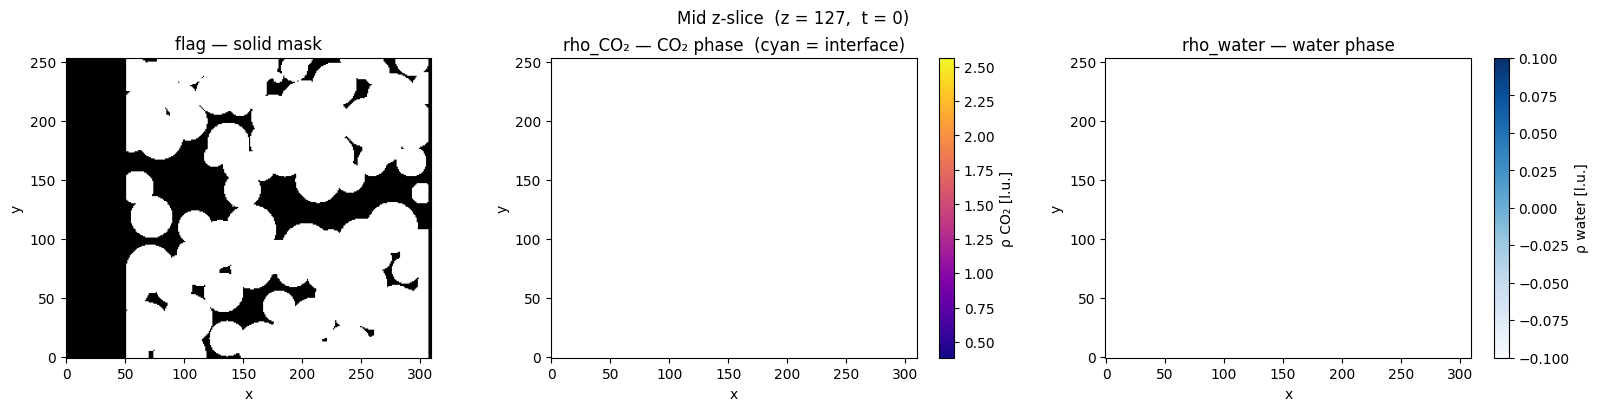

In [2]:
# Middle z-slice
z = NZ // 2
sl_co2   = np.where(flag[:, :, z] < 0.5, rho_co2[:, :, z],   np.nan).T
sl_water = np.where(flag[:, :, z] < 0.5, rho_water[:, :, z], np.nan).T
sl_flag  = flag[:, :, z].T

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig.suptitle(f'Mid z-slice  (z = {z},  t = 0)', fontsize=12)

axes[0].imshow(sl_flag, origin='lower', cmap='Greys_r', vmin=0, vmax=1)
axes[0].set_title('flag — solid mask')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

im1 = axes[1].imshow(sl_co2, origin='lower', cmap='plasma',
                     vmin=RHO_CO2_GAS, vmax=RHO_CO2_LIQUID)
axes[1].contour(np.nan_to_num(sl_co2), levels=[RHO_CO2_MID],
                colors='cyan', linewidths=0.8)
fig.colorbar(im1, ax=axes[1], label='\u03c1 CO\u2082 [l.u.]')
axes[1].set_title('rho_CO\u2082 — CO\u2082 phase  (cyan = interface)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

im2 = axes[2].imshow(sl_water, origin='lower', cmap='Blues')
fig.colorbar(im2, ax=axes[2], label='\u03c1 water [l.u.]')
axes[2].set_title('rho_water — water phase')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')

plt.show()

In [3]:
import ipywidgets as widgets
from IPython.display import display

pv.set_jupyter_backend('trame')
pv.global_theme.trame.server_proxy_enabled = True
pv.global_theme.trame.server_proxy_prefix  = '/proxy/'
pv.global_theme.allow_empty_mesh = True

# Marching cubes on CO2 field masked to pore space
co2_pore = rho_co2.copy()
co2_pore[SOLID] = 0.0

verts, faces, _, vals = marching_cubes(
    co2_pore, level=RHO_CO2_MID, spacing=(1,1,1), allow_degenerate=False
)
faces_pv = np.hstack([np.full((len(faces), 1), 3), faces]).ravel()
co2_surf = pv.PolyData(verts, faces_pv)
co2_surf = co2_surf.smooth(n_iter=30, relaxation_factor=0.1)
co2_surf['rho_CO2'] = vals
print(f'CO\u2082 surface: {co2_surf.n_points:,} pts  {co2_surf.n_cells:,} faces')

# Rock: extract outer shell and decimate for lightweight ghost rendering
rock_surf = (
    m.threshold(0.5, scalars='flag')
     .extract_surface()
     .decimate(0.95)
)
print(f'Rock surface : {rock_surf.n_cells:,} faces (decimated)')

pl = pv.Plotter()
pl.set_background('white')

pl.add_mesh(
    rock_surf,
    color='#c0bab4',
    opacity=0.03,
    smooth_shading=True,
    show_scalar_bar=False,
)
pl.add_mesh(
    co2_surf,
    scalars='rho_CO2',
    cmap='plasma',
    clim=[RHO_CO2_MID, RHO_CO2_LIQUID],
    opacity=0.85,
    smooth_shading=True,
    scalar_bar_args={
        'title': '\u03c1 CO\u2082 [l.u.]',
        'vertical': True,
        'color': 'black',
        'fmt': '%.2f',
        'n_labels': 4,
    },
)

pl.add_text('CO\u2082 injection front  |  t = 0',
            font_size=11, color='black', position='upper_left')
pl.add_axes()
pl.camera_position = 'iso'
pl.show()

RuntimeError: No surface found at the given iso value.